# Week 6 — Complete ROI localizer training on Kaggle

Notebook này thực hiện trọn quy trình: kiểm tra runtime → tìm Dataset → kiểm tra nhãn/split → tạo coarse prediction từ `best.pth` → train ROIRefiner → đánh giá → smoke test → đóng gói checkpoint.

Mô hình mới chỉ tinh chỉnh điểm chân lửa 2D để phục vụ định vị 3D; nó không thay thế detector fire/no-fire upstream.

## Bước 1/16 — Attach input và bật GPU

Trong giao diện Kaggle, attach bốn Dataset: `sam-experiment-code`, `fire-model-data`, `fire-detection-from-cctv` và `fire-localization-img-data` (ZIP ảnh đúng với labels). Nếu upload cả thư mục `fire-detection-from-cctv` đã có `data/data/img_data` thì Dataset thứ tư không bắt buộc. Chọn Accelerator = GPU (T4/P100). Sau đó chạy các cell bên dưới.

In [1]:
from pathlib import Path
import json
import os
import shutil
import subprocess
import sys

INPUT_ROOT = Path('/kaggle/input')
OUTPUT_ROOT = Path('/kaggle/working/week6_roi')
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
print('Input root:', INPUT_ROOT)
print('Attached inputs:')
for item in sorted(INPUT_ROOT.iterdir()):
    print(' -', item)
print('Output:', OUTPUT_ROOT)

Input root: /kaggle/input
Attached inputs:
 - /kaggle/input/datasets
Output: /kaggle/working/week6_roi


## Bước 2/16 — Kiểm tra Python, PyTorch, CUDA và thư viện

In [2]:
print('Python:', sys.version)
try:
    import torch
    print('PyTorch:', torch.__version__)
    print('CUDA available:', torch.cuda.is_available())
    if torch.cuda.is_available():
        print('GPU:', torch.cuda.get_device_name(0))
except Exception as exc:
    raise RuntimeError('PyTorch import failed. Check the Kaggle accelerator/runtime.') from exc

try:
    import timm
    from PIL import Image
    print('timm:', timm.__version__)
    print('Pillow: OK')
except ModuleNotFoundError as exc:
    print('Missing package:', exc.name)
    print('If Internet is enabled, run: %pip install -q timm')
    raise

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
timm: 1.0.26
Pillow: OK


## Bước 3/16 — Tự tìm code, checkpoint, labels và dataset ảnh

Không hardcode tên slug của Kaggle để tránh lỗi khi Kaggle tự đổi tên Dataset.

In [3]:
import zipfile

INPUT_ROOT = Path('/kaggle/input')
WORK_ROOT = Path('/kaggle/working')
SEARCH_ROOTS = [INPUT_ROOT, WORK_ROOT]

def find_all(pattern):
    found = set()
    for root in SEARCH_ROOTS:
        if root.exists():
            found.update(root.rglob(pattern))
    return sorted(found)

# Handle both a normal Kaggle Dataset folder and an uploaded ZIP.
code_files = find_all('train_roi_localizer.py')
if not code_files:
    code_zips = [p for p in find_all('*.zip') if 'sam-experiment-code' in p.name.lower()]
    if code_zips:
        unpack_dir = WORK_ROOT / 'sam-experiment-code-unpacked'
        unpack_dir.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(code_zips[0]) as archive:
            archive.extractall(unpack_dir)
        print('Unpacked code ZIP:', code_zips[0], '->', unpack_dir)
        code_files = find_all('train_roi_localizer.py')
if not code_files:
    raise FileNotFoundError('Không tìm thấy train_roi_localizer.py trong /kaggle/input hoặc ZIP code.')

model_candidates = find_all('best.pth')
label_candidates = find_all('dataset_labels (1).json')
if not model_candidates:
    raise FileNotFoundError('Không tìm thấy best.pth trong /kaggle/input.')
if not label_candidates:
    raise FileNotFoundError('Không tìm thấy dataset_labels (1).json trong /kaggle/input.')

def preferred(paths, token):
    return sorted(paths, key=lambda p: (token not in str(p).lower(), len(str(p))))[0]

CODE_DIR = code_files[0].parent
MODEL_PATH = preferred(model_candidates, 'fire-model-data')
LABELS_PATH = preferred(label_candidates, 'fire-model-data')

# Resolve the image root by matching label paths, not by guessing one
# fixed Kaggle layout. This supports /kaggle/input/datasets/<owner>/... .
raw_labels = json.loads(LABELS_PATH.read_text(encoding='utf-8'))

# Build a canonical local image tree. This removes all ambiguity from
# Kaggle's nested /datasets/<owner>/<dataset> mount and also supports a
# Dataset that contains fire-localization-img-data.zip as a file.
canonical_root = WORK_ROOT / 'label-matched-images' / 'img_data'
label_relatives = {}
for item in raw_labels:
    normalized = str(item['image_path']).replace('\\', '/')
    marker = '/img_data/'
    if marker in normalized:
        relative = normalized.split(marker, 1)[1].lower()
        label_relatives[relative] = relative

matched_sources = {}
image_extensions = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}
for image_path in find_all('*'):
    if not image_path.is_file() or image_path.suffix.lower() not in image_extensions:
        continue
    parts = [part.lower() for part in image_path.parts]
    for position, part in enumerate(parts[:-2]):
        if part in {'train', 'test', 'val'}:
            key = '/'.join(parts[position:position + 3])
            if key in label_relatives:
                matched_sources.setdefault(key, image_path)
            break

# If images are inside a ZIP, locate only members matching the labels.
zip_sources = {}
if len(matched_sources) < len(label_relatives):
    for zip_path in find_all('*.zip'):
        if zip_path.name.lower() in {'sam-experiment-code.zip', 'fire-model-data.zip'}:
            continue
        try:
            with zipfile.ZipFile(zip_path) as archive:
                for member in archive.namelist():
                    normalized_member = member.replace('\\', '/').lower().strip('/')
                    for key in label_relatives:
                        if normalized_member == key or normalized_member.endswith('/' + key):
                            zip_sources.setdefault(key, (zip_path, member))
        except zipfile.BadZipFile:
            continue

all_sources = dict(matched_sources)
for key, value in zip_sources.items():
    all_sources.setdefault(key, value)
if all_sources:
    for key, source in all_sources.items():
        target = canonical_root / key
        target.parent.mkdir(parents=True, exist_ok=True)
        if target.exists():
            continue
        if isinstance(source, tuple):
            zip_path, member = source
            with zipfile.ZipFile(zip_path) as archive, archive.open(member) as source_handle, target.open('wb') as target_handle:
                shutil.copyfileobj(source_handle, target_handle)
        else:
            shutil.copy2(source, target)
    print('Canonical label-matched images:', len(all_sources), '/', len(label_relatives), '->', canonical_root)

# Replace stale absolute Kaggle paths in the original labels with the
# canonical paths that actually exist in this session.
TRAIN_LABELS_PATH = LABELS_PATH
if all_sources and len(all_sources) == len(label_relatives):
    resolved_items = []
    for item in raw_labels:
        normalized = str(item['image_path']).replace('\\', '/')
        key = normalized.split('/img_data/', 1)[1].lower()
        resolved_item = dict(item)
        resolved_item['source_image_path'] = resolved_item['image_path']
        resolved_item['image_path'] = str(canonical_root / key)
        resolved_items.append(resolved_item)
    TRAIN_LABELS_PATH = WORK_ROOT / 'label-matched-images' / 'resolved_labels.json'
    TRAIN_LABELS_PATH.write_text(json.dumps(resolved_items, indent=2), encoding='utf-8')
    print('TRAIN_LABELS_PATH=', TRAIN_LABELS_PATH)

def relative_after_img_data(raw_path):
    normalized = str(raw_path).replace('\\', '/')
    marker = '/img_data/'
    if marker in normalized:
        return Path(normalized.split(marker, 1)[1])
    return Path(Path(normalized).name)

def image_candidates(root, raw_path):
    rel = relative_after_img_data(raw_path)
    name = Path(str(raw_path).replace('\\', '/')).name
    return [
        root / rel,
        root / 'data' / 'data' / 'img_data' / rel,
        root / 'data' / 'img_data' / rel,
        root / 'img_data' / rel,
        root / name,
    ]

image_dirs = find_all('img_data')
root_candidates = set()
for image_dir in image_dirs:
    root_candidates.update({image_dir, image_dir.parent, image_dir.parent.parent, image_dir.parent.parent.parent})

def score_root(root):
    score = 0
    for item in raw_labels:
        if any(path.is_file() for path in image_candidates(root, item['image_path'])):
            score += 1
    return score

# Prefer the shortest outer root when multiple ancestor candidates score
# equally; train_week6.resolve_image_path expects this project root.
scores = sorted(((score_root(root), root) for root in root_candidates),
                key=lambda item: (-item[0], len(item[1].parts), str(item[1])))
if not scores or scores[0][0] == 0:
    # The image dataset may have been uploaded as train.zip. Inspect and
    # unpack only a ZIP that contains the labels' relative image paths.
    label_relatives = {str(relative_after_img_data(item['image_path'])).replace('\\', '/') for item in raw_labels}
    data_zips = [p for p in find_all('*.zip') if p.name.lower() not in {'sam-experiment-code.zip', 'fire-model-data.zip'}]
    for data_zip in data_zips:
        try:
            with zipfile.ZipFile(data_zip) as archive:
                names = {name.replace('\\', '/') for name in archive.namelist()}
            matches = sum(any(name.endswith('/' + rel) or name == rel for name in names) for rel in label_relatives)
            if matches == 0:
                continue
            unpack_dir = WORK_ROOT / 'label-matched-dataset'
            unpack_dir.mkdir(parents=True, exist_ok=True)
            with zipfile.ZipFile(data_zip) as archive:
                archive.extractall(unpack_dir)
            print('Unpacked label-matched dataset ZIP:', data_zip, 'matches=', matches)
            SEARCH_ROOTS.append(unpack_dir)
            image_dirs = find_all('img_data')
            root_candidates = set()
            for image_dir in image_dirs:
                root_candidates.update({image_dir, image_dir.parent, image_dir.parent.parent, image_dir.parent.parent.parent})
            scores = sorted(((score_root(root), root) for root in root_candidates), key=lambda item: (-item[0], len(item[1].parts), str(item[1])))
            if scores and scores[0][0] > 0:
                break
        except zipfile.BadZipFile:
            continue
if not scores or scores[0][0] == 0:
    # Last-resort direct matching: find files by split/class/name and
    # stage them into a canonical img_data tree. This decouples training
    # from Kaggle's arbitrary owner/dataset nesting.
    label_keys = {}
    for item in raw_labels:
        normalized = str(item['image_path']).replace('\\', '/')
        marker = '/img_data/'
        if marker in normalized:
            rel = normalized.split(marker, 1)[1].lower()
            label_keys[rel] = rel
    found_images = {}
    for image_path in find_all('*'):
        if not image_path.is_file() or image_path.suffix.lower() not in {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}:
            continue
        parts = [part.lower() for part in image_path.parts]
        for position, part in enumerate(parts[:-2]):
            if part not in {'train', 'test', 'val'}:
                continue
            key = '/'.join(parts[position:position + 3])
            if key in label_keys:
                found_images.setdefault(key, image_path)
            break
    if found_images:
        staged_root = WORK_ROOT / 'label-matched-images'
        for key, source_path in found_images.items():
            target_path = staged_root / 'img_data' / key
            target_path.parent.mkdir(parents=True, exist_ok=True)
            if not target_path.exists():
                shutil.copy2(source_path, target_path)
        DATASET_ROOT = staged_root
        scores = [(len(found_images), staged_root)]
        print('Staged label-matched images:', len(found_images), '->', DATASET_ROOT)
if not scores or scores[0][0] == 0:
    zip_names = [str(p) for p in find_all('*.zip')]
    image_examples = [str(p) for p in find_all('*.png')[:10]] + [str(p) for p in find_all('*.jpg')[:10]]
    raise FileNotFoundError(
        'Không tìm thấy ảnh khớp với dataset_labels (1).json.\n'
        'Labels cần đường dẫn .../data/data/img_data/{train,test}/..., '
        'nhưng input hiện không có img_data tương ứng.\n'
        f'ZIP đã thấy: {zip_names[:10]}\n'
        f'Một số ảnh hiện có: {image_examples}\n'
        'Bộ cctv-smoke-and-fire.../images chỉ là dataset ngoài, không phải bộ ảnh có p_fire.'
    )
# Always use the canonical staged `img_data` tree when sources were found.
# Passing this exact directory is compatible with old and new loaders:
# both can resolve DATASET_ROOT/{train,test}/{class}/{filename}.
if all_sources:
    DATASET_ROOT = canonical_root
else:
    DATASET_ROOT = scores[0][1]
print('CODE_DIR      =', CODE_DIR)
print('MODEL_PATH   =', MODEL_PATH)
print('LABELS_PATH  =', LABELS_PATH)
print('DATASET_ROOT =', DATASET_ROOT)
print('LABEL_MATCHES=', scores[0][0], '/', len(raw_labels))
print('Candidate dataset roots:', scores[:5])
canonical_probe = list(DATASET_ROOT.rglob('img_103.jpg'))
print('Canonical probe img_103.jpg:', canonical_probe[:3])
if all_sources and len(all_sources) < len(label_relatives):
    missing_keys = sorted(set(label_relatives) - set(all_sources))[:10]
    raise FileNotFoundError(f'Chỉ khớp {len(all_sources)}/{len(label_relatives)} ảnh unique; thiếu ví dụ: {missing_keys}')

# Print a compact ZIP inventory so a wrong external dataset is visible.
zip_inventory = []
for zip_path in find_all('*.zip'):
    try:
        with zipfile.ZipFile(zip_path) as archive:
            names = archive.namelist()
        zip_inventory.append((str(zip_path), len(names), names[:3]))
    except zipfile.BadZipFile:
        zip_inventory.append((str(zip_path), 'BAD_ZIP', []))
print('ZIP inventory:')
for row in zip_inventory:
    print(row)

Canonical label-matched images: 517 / 517 -> /kaggle/working/label-matched-images/img_data
TRAIN_LABELS_PATH= /kaggle/working/label-matched-images/resolved_labels.json
CODE_DIR      = /kaggle/input/datasets/tdl070706/sam-experiment-code/sam-experiment-code
MODEL_PATH   = /kaggle/input/datasets/tdl070706/fire-model-data/fire-model-data/best.pth
LABELS_PATH  = /kaggle/input/datasets/tdl070706/fire-model-data/fire-model-data/dataset_labels (1).json
DATASET_ROOT = /kaggle/working/label-matched-images/img_data
LABEL_MATCHES= 1034 / 1034
Candidate dataset roots: [(1034, PosixPath('/kaggle/working/label-matched-images')), (1034, PosixPath('/kaggle/working/label-matched-images/img_data')), (1034, PosixPath('/kaggle/input/datasets/tdl070706/fire-localization-img-data')), (1034, PosixPath('/kaggle/input/datasets/tdl070706/fire-localization-img-data/img_data')), (0, PosixPath('/kaggle'))]
Canonical probe img_103.jpg: [PosixPath('/kaggle/working/label-matched-images/img_data/test/fire/img_103.jpg'

## Bước 4/16 — Thêm code vào `sys.path` và kiểm tra import

In [4]:
import importlib
sys.path.insert(0, str(CODE_DIR))
# Clear modules from an earlier failed Run All so Kaggle cannot reuse
# an old train_week6.py after the Dataset/code path was corrected.
for module_name in ['train_week6', 'narrow_localizer', 'fire_detector', 'build_coarse_manifest']:
    sys.modules.pop(module_name, None)
importlib.invalidate_caches()
import train_week6
import narrow_localizer
import fire_detector
import build_coarse_manifest
print('Workflow imports: OK')

Workflow imports: OK


## Bước 5/16 — Kiểm tra file nhãn và kích thước dữ liệu

In [5]:
raw_labels = json.loads(TRAIN_LABELS_PATH.read_text(encoding='utf-8'))
print('Raw label records:', len(raw_labels))
print('First record:', json.dumps(raw_labels[0], indent=2)[:1000])
# Re-resolve from the actual image tree as a safety net. This handles a
# Kaggle Dataset mounted below /kaggle/input/datasets/<owner>/... .
canonical_candidates = [
    WORK_ROOT / 'label-matched-images' / 'img_data',
    WORK_ROOT / 'label-matched-dataset' / 'img_data',
]
for canonical_candidate in canonical_candidates:
    if list(canonical_candidate.rglob('img_103.jpg')):
        DATASET_ROOT = canonical_candidate
        print('Using canonical staged DATASET_ROOT:', DATASET_ROOT)
        break
print('DATASET_ROOT before load_records:', DATASET_ROOT)
print('Probe img_103.jpg:', list(Path(DATASET_ROOT).rglob('img_103.jpg'))[:3])
records, stats = train_week6.load_records(TRAIN_LABELS_PATH, DATASET_ROOT)
if not records:
    all_image_dirs = find_all('img_data')
    fallback_roots = []
    for image_dir in all_image_dirs:
        fallback_roots.extend([image_dir, image_dir.parent, image_dir.parent.parent, image_dir.parent.parent.parent])
    for fallback_root in dict.fromkeys(fallback_roots):
        retry_records, retry_stats = train_week6.load_records(TRAIN_LABELS_PATH, fallback_root)
        if retry_records:
            DATASET_ROOT = fallback_root
            records, stats = retry_records, retry_stats
            print('Fallback DATASET_ROOT selected:', DATASET_ROOT)
            break
print('Resolved records:', stats)
if not records:
    raise RuntimeError('Không resolve được ảnh nào. Kiểm tra DATASET_ROOT.')

Raw label records: 1034
First record: {
  "image_path": "/kaggle/working/label-matched-images/img_data/test/fire/img_103.jpg",
  "has_fire": 1,
  "p_fire": [
    0.098214,
    0.745536
  ],
  "source_image_path": "/kaggle/input/datasets/ritupande/fire-detection-from-cctv/data/data/img_data/test/fire/img_103.jpg"
}
Using canonical staged DATASET_ROOT: /kaggle/working/label-matched-images/img_data
DATASET_ROOT before load_records: /kaggle/working/label-matched-images/img_data
Probe img_103.jpg: [PosixPath('/kaggle/working/label-matched-images/img_data/test/fire/img_103.jpg'), PosixPath('/kaggle/working/label-matched-images/img_data/train/fire/img_103.jpg')]
Resolved records: {'indexed_images': 517, 'duplicates': 517, 'loaded': 517, 'fire': 272, 'no_fire': 245}


## Bước 6/16 — Kiểm tra split chống data leakage

In [6]:
splits = train_week6.split_records(records, seed=42)
for name, rows in splits.items():
    fire_count = sum(r.has_fire for r in rows)
    print(f'{name:>5}: total={len(rows):4d}, fire={fire_count:4d}, no_fire={len(rows)-fire_count:4d}')
paths_by_split = {name: {r.image_path.lower() for r in rows} for name, rows in splits.items()}
assert not (paths_by_split['train'] & paths_by_split['val'])
assert not (paths_by_split['train'] & paths_by_split['test'])
assert not (paths_by_split['val'] & paths_by_split['test'])
print('No duplicate image path across splits: OK')

train: total= 338, fire= 201, no_fire= 137
  val: total=  59, fire=  35, no_fire=  24
 test: total= 120, fire=  36, no_fire=  84
No duplicate image path across splits: OK


## Bước 7/16 — Tạo coarse manifest bằng `best.pth`

Bước này chạy detector cũ để tạo điểm đầu vào thực tế cho ROIRefiner. `best.pth` không bị ghi đè.

In [7]:
COARSE_MANIFEST = OUTPUT_ROOT / 'coarse_manifest.json'
command = [
    sys.executable, str(CODE_DIR / 'build_coarse_manifest.py'),
    '--labels', str(TRAIN_LABELS_PATH),
    '--dataset-root', str(DATASET_ROOT),
    '--model', str(MODEL_PATH),
    '--output', str(COARSE_MANIFEST),
    '--threshold', '0.2',
]
print(' '.join(map(str, command)))
subprocess.run(command, check=True)
assert COARSE_MANIFEST.is_file()
print('Saved:', COARSE_MANIFEST, COARSE_MANIFEST.stat().st_size, 'bytes')

/usr/bin/python3 /kaggle/input/datasets/tdl070706/sam-experiment-code/sam-experiment-code/build_coarse_manifest.py --labels /kaggle/working/label-matched-images/resolved_labels.json --dataset-root /kaggle/working/label-matched-images/img_data --model /kaggle/input/datasets/tdl070706/fire-model-data/fire-model-data/best.pth --output /kaggle/working/week6_roi/coarse_manifest.json --threshold 0.2
processed=50/517
processed=100/517
processed=150/517
processed=200/517
processed=250/517
processed=300/517
processed=350/517
processed=400/517
processed=450/517
processed=500/517
processed=517/517
saved=/kaggle/working/week6_roi/coarse_manifest.json records=517
Saved: /kaggle/working/week6_roi/coarse_manifest.json 113299 bytes


## Bước 8/16 — Kiểm tra chất lượng coarse manifest

In [8]:
coarse = json.loads(COARSE_MANIFEST.read_text(encoding='utf-8'))
detected = [v for v in coarse.values() if v.get('point') is not None and v.get('detected')]
print('Manifest records:', len(coarse))
print('Detected with point:', len(detected))
if coarse:
    confidences = [float(v.get('confidence', 0.0)) for v in coarse.values()]
    print('Confidence min/mean/max:', min(confidences), sum(confidences)/len(confidences), max(confidences))
positive_by_split = {}
for name, rows in splits.items():
    positive_by_split[name] = sum(
        coarse.get(r.image_path, {}).get('point') is not None
        for r in rows if r.has_fire
    )
print('Coarse positive points by split:', positive_by_split)

Manifest records: 517
Detected with point: 272
Confidence min/mean/max: 0.0001838207244873047 0.5261100894939046 1.0
Coarse positive points by split: {'train': 201, 'val': 35, 'test': 36}


## Bước 9/16 — Chặn train nếu detector upstream không đủ mẫu

ROIRefiner không thể sửa một ảnh mà detector không tạo được coarse point. Nếu split nào bằng 0, dừng ở đây và chạy lại bước 7 với threshold thấp hơn hoặc kiểm tra `best.pth`.

In [9]:
missing_splits = [name for name, count in positive_by_split.items() if count == 0]
if missing_splits:
    raise RuntimeError(
        f'Không có coarse positive point ở split {missing_splits}. '
        'Thử threshold=0.1 hoặc kiểm tra detector/dataset trước khi train.'
    )
print('All splits have usable coarse positive samples: OK')

All splits have usable coarse positive samples: OK


## Bước 10/16 — Train ROIRefiner

Backbone được khởi tạo từ `best.pth`; head cũ không được dùng. 5 epoch đầu freeze backbone, sau đó fine-tune.

In [10]:
TRAIN_COMMAND = [
    sys.executable, str(CODE_DIR / 'train_roi_localizer.py'),
    '--labels', str(TRAIN_LABELS_PATH),
    '--dataset-root', str(DATASET_ROOT),
    '--init-checkpoint', str(MODEL_PATH),
    '--coarse-manifest', str(COARSE_MANIFEST),
    '--output-dir', str(OUTPUT_ROOT),
    '--epochs', '30',
    '--batch-size', '32',
    '--workers', '2',
    '--freeze-epochs', '5',
    '--lr', '0.0003',
    '--roi-fraction', '0.70',
    '--noise-std', '0.08',
    '--seed', '42',
]
print(' '.join(map(str, TRAIN_COMMAND)))
subprocess.run(TRAIN_COMMAND, check=True)

/usr/bin/python3 /kaggle/input/datasets/tdl070706/sam-experiment-code/sam-experiment-code/train_roi_localizer.py --labels /kaggle/working/label-matched-images/resolved_labels.json --dataset-root /kaggle/working/label-matched-images/img_data --init-checkpoint /kaggle/input/datasets/tdl070706/fire-model-data/fire-model-data/best.pth --coarse-manifest /kaggle/working/week6_roi/coarse_manifest.json --output-dir /kaggle/working/week6_roi --epochs 30 --batch-size 32 --workers 2 --freeze-epochs 5 --lr 0.0003 --roi-fraction 0.70 --noise-std 0.08 --seed 42
coarse_manifest_positive_splits={'train': 201, 'val': 35, 'test': 36}
device=cuda records={'indexed_images': 517, 'duplicates': 517, 'loaded': 517, 'fire': 272, 'no_fire': 245} positive_splits={'train': 201, 'val': 35, 'test': 36}
loaded_backbone=462 missing=0 unexpected=0
epoch=001 train=0.23594 val=0.26965 MAE=18.72px PCK25=0.724
epoch=002 train=0.16319 val=0.20390 MAE=15.46px PCK25=0.938
epoch=003 train=0.11911 val=0.11058 MAE=17.35px PCK2

CompletedProcess(args=['/usr/bin/python3', '/kaggle/input/datasets/tdl070706/sam-experiment-code/sam-experiment-code/train_roi_localizer.py', '--labels', '/kaggle/working/label-matched-images/resolved_labels.json', '--dataset-root', '/kaggle/working/label-matched-images/img_data', '--init-checkpoint', '/kaggle/input/datasets/tdl070706/fire-model-data/fire-model-data/best.pth', '--coarse-manifest', '/kaggle/working/week6_roi/coarse_manifest.json', '--output-dir', '/kaggle/working/week6_roi', '--epochs', '30', '--batch-size', '32', '--workers', '2', '--freeze-epochs', '5', '--lr', '0.0003', '--roi-fraction', '0.70', '--noise-std', '0.08', '--seed', '42'], returncode=0)

## Bước 11/16 — Đọc metric và kiểm tra overfitting

In [11]:
history_path = OUTPUT_ROOT / 'history_roi.json'
metrics_path = OUTPUT_ROOT / 'test_metrics_roi.json'
history = json.loads(history_path.read_text(encoding='utf-8'))
test_metrics = json.loads(metrics_path.read_text(encoding='utf-8'))
print('Epochs:', len(history))
print('Best validation row:')
best_row = min(history, key=lambda row: row['val_loss']['total'])
print(json.dumps(best_row, indent=2))
print('Test metrics:')
print(json.dumps(test_metrics, indent=2))

Epochs: 30
Best validation row:
{
  "epoch": 29,
  "train_loss": {
    "total": 0.0026663475130733693,
    "heatmap": 0.002168363193050027,
    "point": 0.00024899216154345165
  },
  "val_loss": {
    "total": 0.005430960096418858,
    "heatmap": 0.004222190706059337,
    "point": 0.0006043847242835909
  },
  "train_metric": {
    "mae_px": 4.217912146919652,
    "pck10": 0.9816033150020399,
    "pck25": 1.0
  },
  "val_metric": {
    "mae_px": 6.756995439529419,
    "pck10": 0.9375,
    "pck25": 1.0
  }
}
Test metrics:
{
  "loss": {
    "total": 0.009351857472211123,
    "heatmap": 0.005515684140846133,
    "point": 0.0019180866656824946
  },
  "metric": {
    "mae_px": 8.641093969345093,
    "pck10": 0.8125,
    "pck25": 0.921875
  }
}


## Bước 12/16 — Vẽ learning curve và lưu biểu đồ

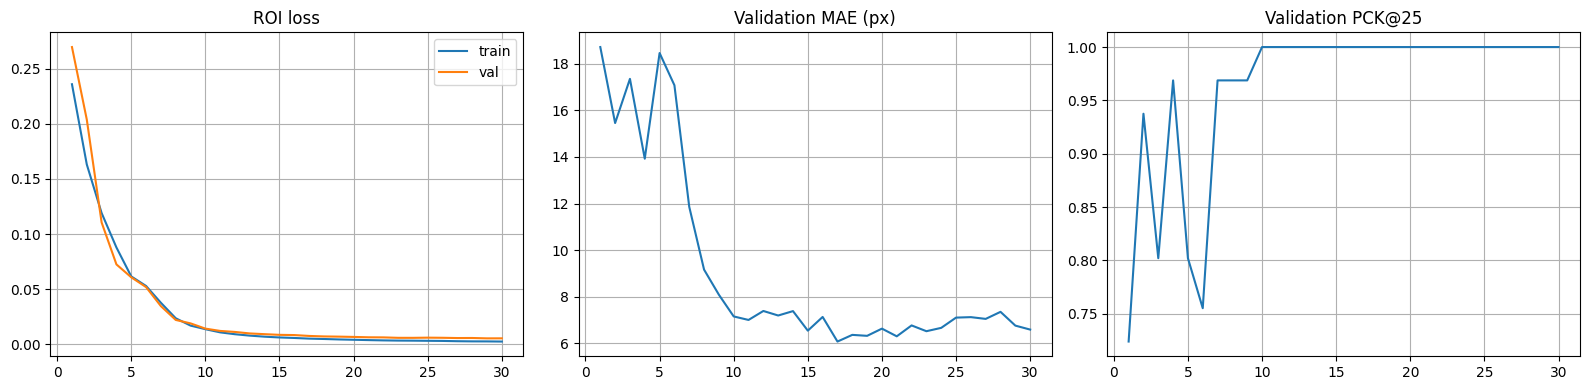

Saved: /kaggle/working/week6_roi/training_curves.png


In [12]:
import matplotlib.pyplot as plt
epochs = [row['epoch'] for row in history]
train_loss = [row['train_loss']['total'] for row in history]
val_loss = [row['val_loss']['total'] for row in history]
val_mae = [row['val_metric']['mae_px'] for row in history]
val_pck25 = [row['val_metric']['pck25'] for row in history]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(epochs, train_loss, label='train')
axes[0].plot(epochs, val_loss, label='val')
axes[0].set_title('ROI loss'); axes[0].legend(); axes[0].grid(True)
axes[1].plot(epochs, val_mae); axes[1].set_title('Validation MAE (px)'); axes[1].grid(True)
axes[2].plot(epochs, val_pck25); axes[2].set_title('Validation PCK@25'); axes[2].grid(True)
fig.tight_layout()
curve_path = OUTPUT_ROOT / 'training_curves.png'
fig.savefig(curve_path, dpi=160)
plt.show()
print('Saved:', curve_path)

## Bước 13/16 — Kiểm tra checkpoint và metadata

In [13]:
BEST_ROI = OUTPUT_ROOT / 'best_roi.pth'
assert BEST_ROI.is_file(), 'Không tạo được best_roi.pth'
checkpoint = torch.load(BEST_ROI, map_location='cpu', weights_only=False)
print('Checkpoint:', BEST_ROI, BEST_ROI.stat().st_size, 'bytes')
print('Architecture:', checkpoint.get('architecture'))
print('Backbone:', checkpoint.get('backbone'))
print('Epoch:', checkpoint.get('epoch'))
print('Validation loss:', checkpoint.get('val_loss'))
print('ROI fraction:', checkpoint.get('roi_fraction'))
assert checkpoint.get('architecture') == 'narrow_roi_localizer_v1'

Checkpoint: /kaggle/working/week6_roi/best_roi.pth 43044847 bytes
Architecture: narrow_roi_localizer_v1
Backbone: mobilenetv4_conv_medium
Epoch: 29
Validation loss: 0.005430960096418858
ROI fraction: 0.7


## Bước 14/16 — Smoke test suy luận ROI trên một ảnh

In [14]:
from narrow_localizer import ROIRefinerInference
positive_records = [r for r in records if r.has_fire and coarse.get(r.image_path, {}).get('point') is not None]
if not positive_records:
    raise RuntimeError('Không có mẫu positive để smoke test.')
sample_record = positive_records[0]
sample_item = coarse[sample_record.image_path]
refiner = ROIRefinerInference(BEST_ROI, device='cuda' if torch.cuda.is_available() else 'cpu')
sample_image = Image.open(sample_record.image_path).convert('RGB')
refined = refiner.refine(sample_image, sample_item['point'])
print('Image:', sample_record.image_path)
print('Coarse point:', sample_item['point'])
print('Refined point:', refined.point)
print('Heatmap confidence:', refined.confidence)

Image: /kaggle/working/label-matched-images/img_data/test/fire/img_103.jpg
Coarse point: [17.240234375, 165.265625]
Refined point: (19.921875, 167.93347930908203)
Heatmap confidence: 0.24292689561843872


## Bước 15/16 — Đóng gói artifact để tải xuống

In [15]:
artifact_base = '/kaggle/working/week6_roi_result'
artifact_zip = shutil.make_archive(artifact_base, 'zip', OUTPUT_ROOT)
print('Artifact:', artifact_zip)
for path in sorted(OUTPUT_ROOT.iterdir()):
    print(path.name, path.stat().st_size, 'bytes')

Artifact: /kaggle/working/week6_roi_result.zip
best_roi.pth 43044847 bytes
coarse_manifest.json 113299 bytes
history_roi.json 16008 bytes
test_metrics_roi.json 221 bytes
training_curves.png 100632 bytes


## Bước 16/16 — Checklist sau khi train

1. Download `week6_roi_result.zip` từ Output của Kaggle.
2. Copy `best_roi.pth` về `D:\LAB\SAM_Experiment\fire-model-data\week6_roi\best_roi.pth`.
3. Dùng calibration thật của camera, không dùng file example khi báo cáo accuracy.
4. Chạy `main_localization.py` với `best.pth` + `best_roi.pth`.
5. Dùng `--sequence` chỉ khi ảnh là frame liên tiếp theo thời gian.
6. Đánh giá `oracle`, `noisy` và `detector` riêng; chỉ báo cáo absolute 3D error khi có ground truth 3D vật lý.

Checkpoint mới phục vụ ROI localization; detector upstream vẫn giữ vai trò fire/no-fire và tạo coarse point.